In [17]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

from hubble_utils import *
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
results_dir = Path("results/cosmo/mar9f_test")

rows = []

file_path = sorted(results_dir.iterdir())[0]

result = load_cosmo_results_hdf5(str(file_path))
print(f"Cosmo Result: ", result)
for model in ['FlatLambdaCDM', 'FlatwCDM', 'Flatw0waCDM']:
    N, z_i, z_f = result[model]["N"], result[model]['z_i'], result[model]['z_f']
    logZ = result[model]['logZ']
    print(f"For model {model}: {N=}, {z_i=}, {z_f=}")
    print("All results for the model: ", result[model].keys())
    print("\n")


Cosmo Result:  {'FlatLambdaCDM': {'H0': np.float64(73.47935765679885), 'H0_err': np.float64(0.9630383424994307), 'M0_agn': np.float64(-22.135943914065894), 'M0_agn_err': np.float64(0.06436044990708645), 'M0_sn': np.float64(-19.24286534830305), 'M0_sn_err': np.float64(0.028269807864148788), 'N': np.int64(2000), 'Om0': np.float64(0.33881552381199936), 'Om0_err': np.float64(0.01761183203554592), 'age': np.float64(12.408323254789732), 'age_err': np.float64(0.22729533894223916), 'alpha_agn': np.float64(4.639357067517125), 'alpha_agn_err': np.float64(0.29887435585600697), 'beta_agn': np.float64(-1.3557275383535128), 'beta_agn_err': np.float64(0.1265008189712601), 'logZ': np.float64(4156.610730056744), 'logZerr': np.float64(0.3167277202175046), 'log_f': np.float64(-0.10366745432357316), 'log_f_err': np.float64(0.03971428709985547), 'z_f': np.float64(1.5), 'z_i': np.float64(0.44)}, 'Flatw0waCDM': {'H0': np.float64(73.03550119706634), 'H0_err': np.float64(1.0603721675188567), 'M0_agn': np.float

In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("results/cosmo/mar11b_test")

rows = []

fields = ["cosmo_model", "logZ", "logZerr", "N", "z_f", 
          "Om0", "Om0_err_upper", "Om0_err_lower",
          "w0", "w0_err_upper", "w0_err_lower",
          "wa", "wa_err_upper", "wa_err_lower"]

for file_path in sorted(results_dir.iterdir()):
    if not file_path.is_file():
        continue

    result = load_cosmo_results_hdf5(str(file_path))

    for model in ["FlatLambdaCDM", "FlatwCDM", "Flatw0waCDM"]:
        row = {"cosmo_model": model}
        row.update({f: result[model].get(f, np.nan) for f in fields if f != "cosmo_model"})
        rows.append(row)

df = pd.DataFrame(rows)
df = df[df["N"].isin([1000, 3000, 5000, 7000])]
df = df.sort_values(["N", "z_f", "cosmo_model"]).reset_index(drop=True)

df.head()

,cosmo_model,logZ,logZerr,N,z_f,Om0,Om0_err_upper,Om0_err_lower,w0,w0_err_upper,w0_err_lower,wa,wa_err_upper,wa_err_lower
0,FlatLambdaCDM,2821.486079,0.308224,1000,1.0,0.332352,0.350012,0.313708,NaN,NaN,NaN,NaN,NaN,NaN
1,Flatw0waCDM,2817.364991,0.329608,1000,1.0,0.405789,0.475829,0.304190,-0.940780,-0.793890,-1.099412,-1.727057,0.128358,-4.994088
2,FlatwCDM,2818.735785,0.324034,1000,1.0,0.307189,0.367229,0.233401,-0.935406,-0.791443,-1.105443,NaN,NaN,NaN
3,FlatLambdaCDM,3171.205902,0.307431,1000,1.5,0.334801,0.351638,0.316364,NaN,NaN,NaN,NaN,NaN,NaN
4,Flatw0waCDM,3167.533949,0.325270,1000,1.5,0.450918,0.516349,0.350622,-0.942848,-0.718903,-1.115584,-3.127689,-0.288815,-8.829419


In [20]:
import numpy as np

def odds_sigmas_from_logZ(logZ_a, logZ_b, logZ_a_err, logZ_b_err):
    """
    Compute:
        delta     = logZ_a - logZ_b
        delta_err = sqrt(logZ_a_err^2 + logZ_b_err^2)   [independent errors]
        sigma     = sqrt(2 * |delta|)
        sigma_err = delta_err / sqrt(2 * |delta|)

    Returns
    -------
    delta, delta_err, sigma, sigma_err
    """
    logZ_a = np.asarray(logZ_a, dtype=float)
    logZ_b = np.asarray(logZ_b, dtype=float)
    logZ_a_err = np.asarray(logZ_a_err, dtype=float)
    logZ_b_err = np.asarray(logZ_b_err, dtype=float)

    delta = logZ_a - logZ_b
    delta_err = np.sqrt(logZ_a_err**2 + logZ_b_err**2)

    abs_delta = np.abs(delta)
    sigma = np.sqrt(2.0 * abs_delta)

    sigma_err = np.full_like(sigma, np.inf, dtype=float)
    mask = abs_delta > 0
    sigma_err[mask] = delta_err[mask] / np.sqrt(2.0 * abs_delta[mask])

    return delta, delta_err, sigma, sigma_err

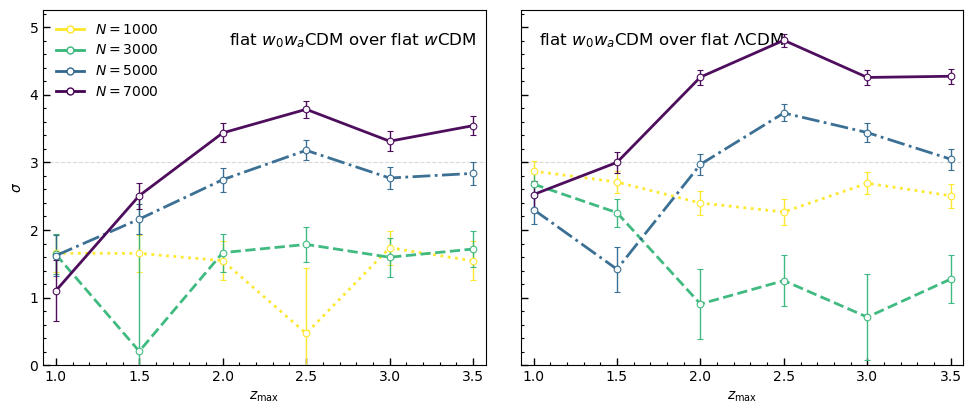

In [24]:
# Pivot so each row is one (N, z_f), with columns for logZ and logZerr of each cosmology
df_logZ = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZ")
df_logZerr = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZerr")

dfw = pd.concat(
    {
        "logZ": df_logZ,
        "logZerr": df_logZerr,
    },
    axis=1,
).reset_index()

# Compute delta, delta_err, sigma, sigma_err for Flatw0waCDM vs FlatwCDM
res_w = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatwCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatwCDM")],
)

dfw["delta_w0wa_minus_w"] = res_w[0]
dfw["deltaerr_w0wa_minus_w"] = res_w[1]
dfw["sigma_w0wa_vs_w"] = res_w[2]
dfw["sigmaerr_w0wa_vs_w"] = res_w[3]

# Compute delta, delta_err, sigma, sigma_err for Flatw0waCDM vs FlatLambdaCDM
res_lcdm = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatLambdaCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatLambdaCDM")],
)

dfw["delta_w0wa_minus_lcdm"] = res_lcdm[0]
dfw["deltaerr_w0wa_minus_lcdm"] = res_lcdm[1]
dfw["sigma_w0wa_vs_lcdm"] = res_lcdm[2]
dfw["sigmaerr_w0wa_vs_lcdm"] = res_lcdm[3]

dfw = dfw.sort_values(["N", "z_f"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True, sharey=True)

Ns = np.array(sorted(dfw["N"].unique()))

# ---- discrete colormap for N ----
base_cmap = plt.cm.viridis_r
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0, 1, len(Ns))))

if len(Ns) > 1:
    boundaries = np.concatenate([
        [Ns[0] - 0.5 * (Ns[1] - Ns[0])],
        0.5 * (Ns[:-1] + Ns[1:]),
        [Ns[-1] + 0.5 * (Ns[-1] - Ns[-2])]
    ])
else:
    boundaries = np.array([Ns[0] - 0.5, Ns[0] + 0.5])

norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)

for N in Ns:
    sub = dfw[dfw["N"] == N].sort_values("z_f")
    color = cmap(norm(N))

    # Rotate linestyle by N index
    line_styles = [":", "--", "-.", "-"]
    iN = np.where(Ns == N)[0][0]
    ls = line_styles[iN % len(line_styles)]

    axes[0].errorbar(
        sub["z_f"],
        sub["sigma_w0wa_vs_w"],
        yerr=sub["sigmaerr_w0wa_vs_w"],
        fmt="o",
        linestyle=ls,
        color=color,
        lw=2,
        ms=4.8,
        mew=0.8,
        mfc="white",
        elinewidth=1.0,
        capsize=2.5,
        capthick=1.0,
        alpha=0.95,
        zorder=3,
    )

    axes[1].errorbar(
        sub["z_f"],
        sub["sigma_w0wa_vs_lcdm"],
        yerr=sub["sigmaerr_w0wa_vs_lcdm"],
        fmt="o",
        linestyle=ls,
        color=color,
        lw=2,
        ms=4.8,
        mew=0.8,
        mfc="white",
        elinewidth=1.0,
        capsize=2.5,
        capthick=1.0,
        alpha=0.95,
        zorder=3,
    )

axes[0].text(
    0.98, 0.94,
    r"flat $w_0w_a$CDM over flat $w$CDM",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    color="k",
    fontsize=12,
    alpha=1,
)
axes[1].text(
    0.04, 0.94,
    r"flat $w_0w_a$CDM over flat $\Lambda$CDM",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    color="k",
    fontsize=12,
    alpha=1,
)

axes[0].set_xlabel(r"$z_{\max}$")
axes[1].set_xlabel(r"$z_{\max}$")
axes[0].set_ylabel(r"$\sigma$")

# Clean ticks, no grid
for ax in axes:
    ax.set_ylim(bottom=0)
    ax.grid(False)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)
    ax.margins(x=0.03)

# Reference lines
for ax in axes:
    for y in [3]:
        ax.axhline(y, color="0.85", lw=0.8, ls="--", zorder=1)

# Legend for N (matching line colors/markers)
legend_handles = [
    mpl.lines.Line2D(
        [], [], color=cmap(norm(n)), marker="o", lw=2, ms=5,
        mfc="white", mec=cmap(norm(n)), label=fr"$N={int(n)}$"
    )
    for n in Ns
]

axes[0].legend(
    handles=legend_handles,
    #title=r"$N$",
    loc="upper left",
    frameon=False,
    ncol=1,
)

# Layout
fig.subplots_adjust(left=0.08, right=0.88, bottom=0.14, top=0.88, wspace=0.08)
os.makedirs("plots/appendix", exist_ok=True)
plt.savefig("plots/appendix/N_vs_logZ_grid.png", dpi=300)
plt.savefig("plots/appendix/N_vs_logZ_grid.pdf")
plt.show()

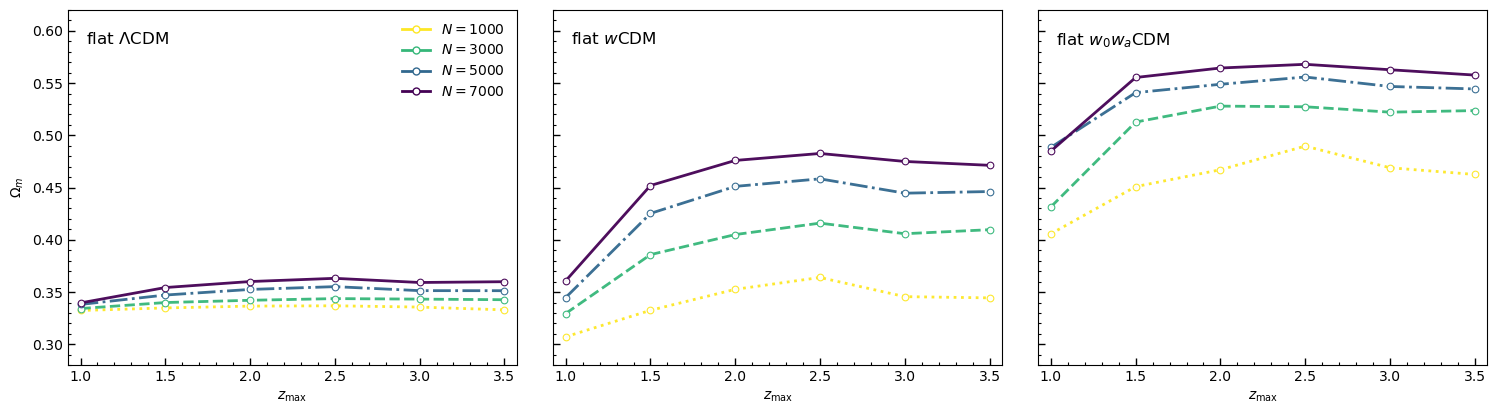

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Expect df to contain:
#   N, z_f, cosmo_model, Om0, Om0_err_lower, Om0_err_upper
# ------------------------------------------------------------------

df_om = df.copy().sort_values(["cosmo_model", "N", "z_f"]).reset_index(drop=True)

model_order = ["FlatLambdaCDM", "FlatwCDM", "Flatw0waCDM"]
model_labels = {
    "FlatLambdaCDM": r"flat $\Lambda$CDM",
    "FlatwCDM": r"flat $w$CDM",
    "Flatw0waCDM": r"flat $w_0w_a$CDM",
}

# Keep only models that are actually present
model_order = [m for m in model_order if m in df_om["cosmo_model"].unique()]

fig, axes = plt.subplots(
    1, len(model_order), figsize=(5.2 * len(model_order), 4.8), sharex=True, sharey=True
)

if len(model_order) == 1:
    axes = [axes]

Ns = np.array(sorted(df_om["N"].unique()))

# ---- discrete colormap for N ----
base_cmap = plt.cm.viridis_r
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0, 1, len(Ns))))

if len(Ns) > 1:
    boundaries = np.concatenate([
        [Ns[0] - 0.5 * (Ns[1] - Ns[0])],
        0.5 * (Ns[:-1] + Ns[1:]),
        [Ns[-1] + 0.5 * (Ns[-1] - Ns[-2])]
    ])
else:
    boundaries = np.array([Ns[0] - 0.5, Ns[0] + 0.5])

norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)

line_styles = [":", "--", "-.", "-"]

for ax, model in zip(axes, model_order):
    dfm = df_om[df_om["cosmo_model"] == model].copy()

    for iN, N in enumerate(Ns):
        sub = dfm[dfm["N"] == N].sort_values("z_f")
        if sub.empty:
            continue

        color = cmap(norm(N))
        ls = line_styles[iN % len(line_styles)]

        y = sub["Om0"].to_numpy()
        yerr_lower = sub["Om0_err_lower"].to_numpy()
        yerr_upper = sub["Om0_err_upper"].to_numpy()
        yerr = np.vstack([yerr_lower, yerr_upper])

        ax.errorbar(
            sub["z_f"],
            y,
            #yerr=yerr,
            fmt="o",
            linestyle=ls,
            color=color,
            lw=2,
            ms=4.8,
            mew=0.8,
            mfc="white",
            elinewidth=1.0,
            capsize=2.5,
            capthick=1.0,
            alpha=0.95,
            zorder=3,
        )

    ax.text(
        0.04, 0.94,
        model_labels.get(model, model),
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="k",
        fontsize=12,
        alpha=1,
    )

    ax.set_xlabel(r"$z_{\max}$")
    ax.grid(False)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)
    ax.margins(x=0.03)
    ax.set_ylim(0.28, 0.62)

axes[0].set_ylabel(r"$\Omega_m$")

# Optional horizontal reference lines
#for ax in axes:
    #ax.axhline(0.3, color="0.85", lw=0.8, ls="--", zorder=1)

# Legend for N
legend_handles = [
    mpl.lines.Line2D(
        [], [], color=cmap(norm(n)), marker="o", lw=2, ms=5,
        mfc="white", mec=cmap(norm(n)), label=fr"$N={int(n)}$"
    )
    for n in Ns
]

axes[0].legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    ncol=1,
)

# Layout
fig.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.14,
    top=0.88,
    wspace=0.08,
)

os.makedirs("plots/appendix", exist_ok=True)
plt.savefig("plots/appendix/N_vs_Om0_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/appendix/N_vs_Om0_grid.pdf", bbox_inches="tight")
plt.show()

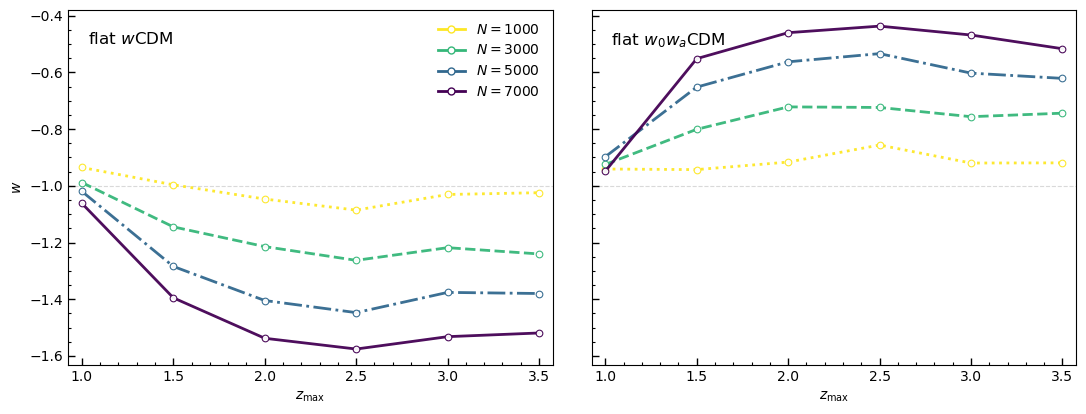

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Expect df to contain:
#   N, z_f, cosmo_model, w0, w0_err_lower, w0_err_upper
# where:
#   w0_err_lower = median - p16
#   w0_err_upper = p84 - median
# ------------------------------------------------------------------

df_w = df.copy().sort_values(["cosmo_model", "N", "z_f"]).reset_index(drop=True)

model_order = ["FlatwCDM", "Flatw0waCDM"]
model_labels = {
    "FlatwCDM": r"flat $w$CDM",
    "Flatw0waCDM": r"flat $w_0w_a$CDM",
}

# Keep only models that are actually present
model_order = [m for m in model_order if m in df_w["cosmo_model"].unique()]

fig, axes = plt.subplots(
    1, len(model_order), figsize=(5.6 * len(model_order), 4.8), sharex=True, sharey=True
)

if len(model_order) == 1:
    axes = [axes]

Ns = np.array(sorted(df_w["N"].unique()))

# ---- discrete colormap for N ----
base_cmap = plt.cm.viridis_r
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0, 1, len(Ns))))

if len(Ns) > 1:
    boundaries = np.concatenate([
        [Ns[0] - 0.5 * (Ns[1] - Ns[0])],
        0.5 * (Ns[:-1] + Ns[1:]),
        [Ns[-1] + 0.5 * (Ns[-1] - Ns[-2])]
    ])
else:
    boundaries = np.array([Ns[0] - 0.5, Ns[0] + 0.5])

norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)
line_styles = [":", "--", "-.", "-"]

for ax, model in zip(axes, model_order):
    dfm = df_w[df_w["cosmo_model"] == model].copy()

    for iN, N in enumerate(Ns):
        sub = dfm[dfm["N"] == N].sort_values("z_f")
        if sub.empty:
            continue

        color = cmap(norm(N))
        ls = line_styles[iN % len(line_styles)]

        y = sub["w0"].to_numpy()
        yerr_lower = sub["w0_err_lower"].to_numpy()
        yerr_upper = sub["w0_err_upper"].to_numpy()
        yerr = np.vstack([yerr_lower, yerr_upper])

        ax.errorbar(
            sub["z_f"],
            y,
            #yerr=yerr,
            fmt="o",
            linestyle=ls,
            color=color,
            lw=2,
            ms=4.8,
            mew=0.8,
            mfc="white",
            elinewidth=1.0,
            capsize=2.5,
            capthick=1.0,
            alpha=0.95,
            zorder=3,
        )

    ax.text(
        0.04, 0.94,
        model_labels.get(model, model),
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="k",
        fontsize=12,
    )

    ax.set_xlabel(r"$z_{\max}$")
    ax.grid(False)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)
    ax.margins(x=0.03)

axes[0].set_ylabel(r"$w$")

# Reference line for cosmological constant
for ax in axes:
    ax.axhline(-1.0, color="0.85", lw=0.8, ls="--", zorder=1)

legend_handles = [
    mpl.lines.Line2D(
        [], [], color=cmap(norm(n)), marker="o", lw=2, ms=5,
        mfc="white", mec=cmap(norm(n)), label=fr"$N={int(n)}$"
    )
    for n in Ns
]

axes[0].legend(
    handles=legend_handles,
    loc="best",
    frameon=False,
    ncol=1,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.14,
    top=0.88,
    wspace=0.08,
)

os.makedirs("plots/appendix", exist_ok=True)
plt.savefig("plots/appendix/N_vs_w_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/appendix/N_vs_w_grid.pdf", bbox_inches="tight")
plt.show()

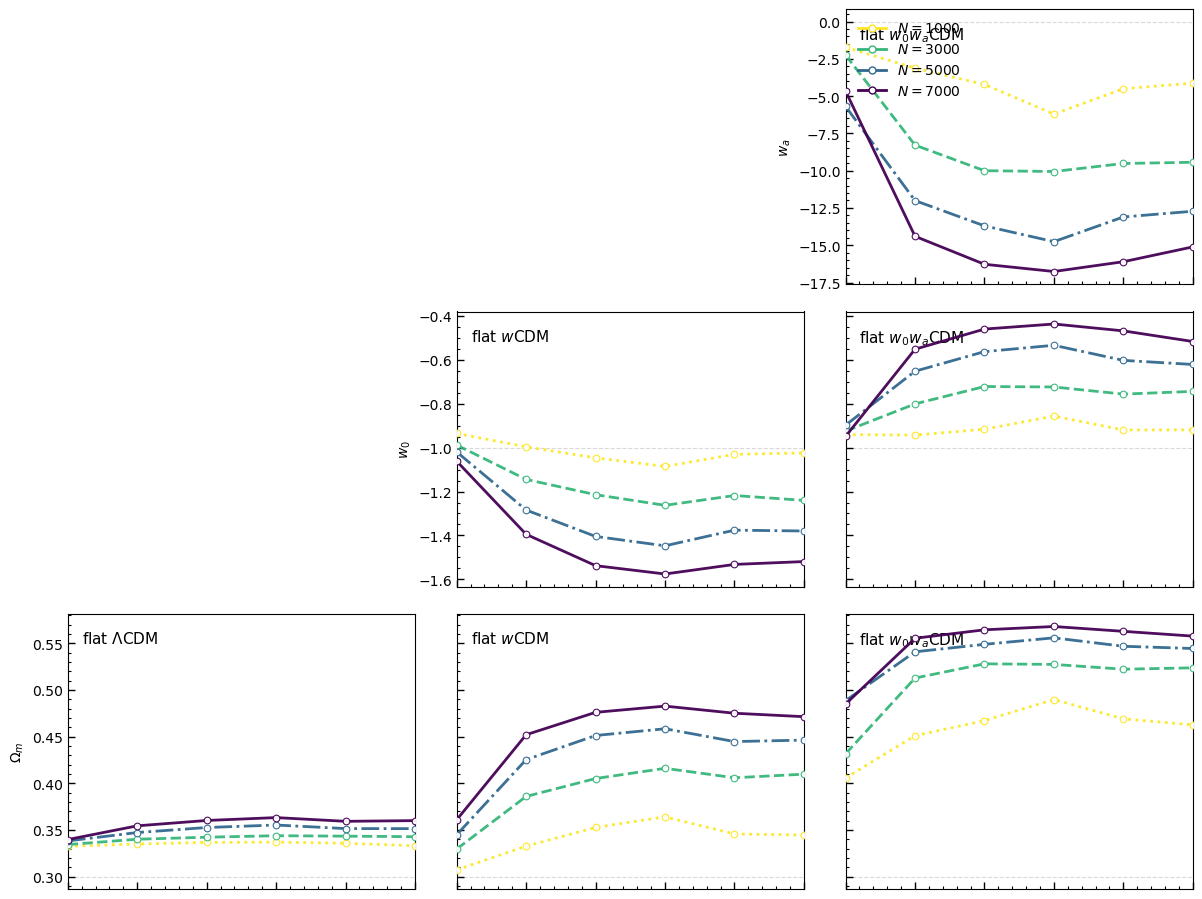

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------------
# Assumes df contains at least:
#   N, z_f, cosmo_model,
#   logZ, logZerr,
#   Om0, Om0_err_lower, Om0_err_upper,
#   w0,  w0_err_lower,  w0_err_upper,
#   wa,  wa_err_lower,  wa_err_upper
#
# IMPORTANT:
#   *_err_lower and *_err_upper must be true asymmetric errors:
#       err_lower = median - p16
#       err_upper = p84 - median
# ------------------------------------------------------------------

# ----------------------------
# Build sigma comparisons
# ----------------------------
df_logZ = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZ")
df_logZerr = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZerr")

dfw = pd.concat(
    {
        "logZ": df_logZ,
        "logZerr": df_logZerr,
    },
    axis=1,
).reset_index()

# flat wCDM over flat LCDM
res_w_minus_lcdm = odds_sigmas_from_logZ(
    dfw[("logZ", "FlatwCDM")],
    dfw[("logZ", "FlatLambdaCDM")],
    dfw[("logZerr", "FlatwCDM")],
    dfw[("logZerr", "FlatLambdaCDM")],
)
dfw["sigma_w_vs_lcdm"] = res_w_minus_lcdm[2]
dfw["sigmaerr_w_vs_lcdm"] = res_w_minus_lcdm[3]

# flat w0waCDM over flat wCDM
res_w0wa_minus_w = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatwCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatwCDM")],
)
dfw["sigma_w0wa_vs_w"] = res_w0wa_minus_w[2]
dfw["sigmaerr_w0wa_vs_w"] = res_w0wa_minus_w[3]

# flat w0waCDM over flat LCDM
res_w0wa_minus_lcdm = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatLambdaCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatLambdaCDM")],
)
dfw["sigma_w0wa_vs_lcdm"] = res_w0wa_minus_lcdm[2]
dfw["sigmaerr_w0wa_vs_lcdm"] = res_w0wa_minus_lcdm[3]

dfw = dfw.sort_values(["N", "z_f"]).reset_index(drop=True)

# ----------------------------
# Style helpers
# ----------------------------
dfp = df.copy().sort_values(["cosmo_model", "N", "z_f"]).reset_index(drop=True)

Ns = np.array(sorted(dfp["N"].unique()))

base_cmap = plt.cm.viridis_r
cmap = mpl.colors.ListedColormap(base_cmap(np.linspace(0, 1, len(Ns))))

if len(Ns) > 1:
    boundaries = np.concatenate([
        [Ns[0] - 0.5 * (Ns[1] - Ns[0])],
        0.5 * (Ns[:-1] + Ns[1:]),
        [Ns[-1] + 0.5 * (Ns[-1] - Ns[-2])]
    ])
else:
    boundaries = np.array([Ns[0] - 0.5, Ns[0] + 0.5])

norm = mpl.colors.BoundaryNorm(boundaries, cmap.N)
line_styles = [":", "--", "-.", "-"]

def style_ax(ax, show_xlabel=False, ylabel=None, hide_left_labels=False):
    ax.grid(False)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, width=0.8)
    ax.margins(x=0.03)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if show_xlabel:
        ax.set_xlabel(r"$z_{\max}$")
    else:
        ax.tick_params(labelbottom=False)

    if hide_left_labels:
        ax.tick_params(labelleft=False)

def plot_param_panel(
    ax,
    model,
    ycol,
    yerr_lo_col,
    yerr_hi_col,
    panel_text,
    show_xlabel=False,
    ylabel=None,
    refline=None,
    hide_left_labels=False,
):
    subm = dfp[dfp["cosmo_model"] == model].copy()

    for iN, N in enumerate(Ns):
        sub = subm[subm["N"] == N].sort_values("z_f")
        if sub.empty:
            continue

        color = cmap(norm(N))
        ls = line_styles[iN % len(line_styles)]

        yerr = np.vstack([
            sub[yerr_lo_col].to_numpy(),
            sub[yerr_hi_col].to_numpy(),
        ])

        ax.errorbar(
            sub["z_f"],
            sub[ycol].to_numpy(),
            #yerr=yerr,
            fmt="o",
            linestyle=ls,
            color=color,
            lw=2,
            ms=4.8,
            mew=0.8,
            mfc="white",
            elinewidth=1.0,
            capsize=2.5,
            capthick=1.0,
            alpha=0.95,
            zorder=3,
        )

    if refline is not None:
        ax.axhline(refline, color="0.85", lw=0.8, ls="--", zorder=1)

    ax.text(
        0.04, 0.94,
        panel_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
    )

    style_ax(
        ax,
        show_xlabel=show_xlabel,
        ylabel=ylabel,
        hide_left_labels=hide_left_labels,
    )


# ----------------------------
# Figure layout: corner-like half grid
# ----------------------------
fig = plt.figure(figsize=(12.5, 10.0))
gs = fig.add_gridspec(
    3, 3,
    left=0.08, right=0.98, bottom=0.08, top=0.96,
    wspace=0.12, hspace=0.10
)

# Top row: wa (1 panel)
ax_wa = fig.add_subplot(gs[0, 2])

# Row 2: w0 (share y within row)
ax_w0_w = fig.add_subplot(gs[1, 1])
ax_w0_w0wa = fig.add_subplot(gs[1, 2], sharey=ax_w0_w)

# Row 3: Om0 (share y within row)
ax_om_lcdm = fig.add_subplot(gs[2, 0])
ax_om_w = fig.add_subplot(gs[2, 1], sharey=ax_om_lcdm)
ax_om_w0wa = fig.add_subplot(gs[2, 2], sharey=ax_om_lcdm)

# ----------------------------
# Plot rows
# ----------------------------

# wa
plot_param_panel(
    ax_wa,
    model="Flatw0waCDM",
    ycol="wa",
    yerr_lo_col="wa_err_lower",
    yerr_hi_col="wa_err_upper",
    panel_text=r"flat $w_0w_a$CDM",
    show_xlabel=False,
    ylabel=r"$w_a$",
    refline=0.0,
    hide_left_labels=False,
)

# w0
plot_param_panel(
    ax_w0_w,
    model="FlatwCDM",
    ycol="w0",
    yerr_lo_col="w0_err_lower",
    yerr_hi_col="w0_err_upper",
    panel_text=r"flat $w$CDM",
    show_xlabel=False,
    ylabel=r"$w_0$",
    refline=-1.0,
    hide_left_labels=False,
)

plot_param_panel(
    ax_w0_w0wa,
    model="Flatw0waCDM",
    ycol="w0",
    yerr_lo_col="w0_err_lower",
    yerr_hi_col="w0_err_upper",
    panel_text=r"flat $w_0w_a$CDM",
    show_xlabel=False,
    ylabel=None,
    refline=-1.0,
    hide_left_labels=True,
)

# Om0
plot_param_panel(
    ax_om_lcdm,
    model="FlatLambdaCDM",
    ycol="Om0",
    yerr_lo_col="Om0_err_lower",
    yerr_hi_col="Om0_err_upper",
    panel_text=r"flat $\Lambda$CDM",
    show_xlabel=False,
    ylabel=r"$\Omega_m$",
    refline=0.3,
    hide_left_labels=False,
)

plot_param_panel(
    ax_om_w,
    model="FlatwCDM",
    ycol="Om0",
    yerr_lo_col="Om0_err_lower",
    yerr_hi_col="Om0_err_upper",
    panel_text=r"flat $w$CDM",
    show_xlabel=False,
    ylabel=None,
    refline=0.3,
    hide_left_labels=True,
)

plot_param_panel(
    ax_om_w0wa,
    model="Flatw0waCDM",
    ycol="Om0",
    yerr_lo_col="Om0_err_lower",
    yerr_hi_col="Om0_err_upper",
    panel_text=r"flat $w_0w_a$CDM",
    show_xlabel=False,
    ylabel=None,
    refline=0.3,
    hide_left_labels=True,
)

# sigma row in requested order:
# 1) wCDM / LCDM
# 2) w0waCDM / wCDM
# 3) w0waCDM / LCDM

# plot_sigma_panel(
#     ax_sig_w_lcdm,
#     ycol="sigma_w_vs_lcdm",
#     yerrcol="sigmaerr_w_vs_lcdm",
#     panel_text=r"flat $w$CDM over flat $\Lambda$CDM",
#     show_xlabel=True,
#     ylabel=r"$\sigma$",
#     refline=3.0,
#     hide_left_labels=False,
# )

# plot_sigma_panel(
#     ax_sig_w0wa_w,
#     ycol="sigma_w0wa_vs_w",
#     yerrcol="sigmaerr_w0wa_vs_w",
#     panel_text=r"flat $w_0w_a$CDM over flat $w$CDM",
#     show_xlabel=True,
#     ylabel=None,
#     refline=3.0,
#     hide_left_labels=True,
# )

# plot_sigma_panel(
#     ax_sig_w0wa_lcdm,
#     ycol="sigma_w0wa_vs_lcdm",
#     yerrcol="sigmaerr_w0wa_vs_lcdm",
#     panel_text=r"flat $w_0w_a$CDM over flat $\Lambda$CDM",
#     show_xlabel=True,
#     ylabel=None,
#     refline=3.0,
#     hide_left_labels=True,
# )

# ----------------------------
# Legend for N
# ----------------------------
legend_handles = [
    mpl.lines.Line2D(
        [], [],
        color=cmap(norm(n)),
        marker="o",
        lw=2,
        ms=5,
        mfc="white",
        mec=cmap(norm(n)),
        label=fr"$N={int(n)}$"
    )
    for n in Ns
]

ax_wa.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=False,
    ncol=1,
)

# ----------------------------
# Shared x-limits for all visible panels
# ----------------------------
zmin = df["z_f"].min()
zmax = df["z_f"].max()

for ax in [
    ax_wa,
    ax_w0_w, ax_w0_w0wa,
    ax_om_lcdm, ax_om_w, ax_om_w0wa,
    ax_sig_w_lcdm, ax_sig_w0wa_w, ax_sig_w0wa_lcdm,
]:
    ax.set_xlim(zmin, zmax)

# ----------------------------
# Save
# ----------------------------
os.makedirs("plots/appendix", exist_ok=True)
plt.savefig("plots/appendix/half_corner_cosmo_grid.png", dpi=300, bbox_inches="tight")
plt.savefig("plots/appendix/half_corner_cosmo_grid.pdf", bbox_inches="tight")
plt.show()